# Decision Tree Classifier for Customer Churn Prediction

## Objective

The objective of this notebook is to develop a Decision Tree classifier for predicting customer churn and compare its performance with the baseline Logistic Regression model developed previously.

Unlike Logistic Regression, which assumes a linear relationship between the features and the target, Decision Trees can learn complex non-linear decision boundaries by recursively splitting the feature space.

This notebook will cover:

- Building a baseline Decision Tree model
- Evaluating model performance using Cross Validation
- Hyperparameter tuning using GridSearchCV
- Feature importance analysis
- Comparison with the Logistic Regression baseline
- Saving the best-performing model for deployment

In [1]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder
)

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn import set_config

set_config(display="diagram")

## Load Feature Engineered Dataset

The feature engineered dataset generated in Notebook 03 is used for training the Decision Tree model.

Using the same dataset ensures that the comparison with Logistic Regression is fair, since only the learning algorithm changes while the data preparation remains identical.

In [2]:
df = pd.read_csv("../data/processed/telco_feature_engineered.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Binary,AvgMonthlySpend,TotalServices,HasFamily,TenureGroup,SpendingGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Electronic check,29.85,29.85,No,0,29.850000,1,0,New,Low
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Mailed check,56.95,1889.50,No,0,55.573529,3,0,Established,Medium
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Mailed check,53.85,108.15,Yes,1,54.075000,3,0,New,Medium
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Bank transfer (automatic),42.30,1840.75,No,0,40.905556,3,0,Established,Low
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Electronic check,70.70,151.65,Yes,1,75.825000,1,0,New,Medium


## Define Features and Target

The customer identifier and target-related columns are excluded from the feature matrix.

The binary churn indicator is used as the prediction target.

In [3]:
X = df.drop(
    columns=[
        "customerID",
        "Churn",
        "Churn_Binary"
    ]
)

y = df["Churn_Binary"]

print("Feature Matrix :", X.shape)
print("Target Vector  :", y.shape)

Feature Matrix : (7032, 24)
Target Vector  : (7032,)


In [4]:
continuous_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "AvgMonthlySpend",
    "TotalServices"
]

binary_features = [
    "SeniorCitizen",
    "HasFamily"
]

nominal_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

ordinal_features = [
    "TenureGroup",
    "SpendingGroup"
]

## Train-Test Split

The dataset is divided into training and testing subsets using Stratified Sampling.

Stratification preserves the original class distribution in both subsets, ensuring a reliable evaluation of model performance.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)

print("Testing Samples  :", X_test.shape)

Training Samples : (5625, 24)
Testing Samples  : (1407, 24)


In [6]:
preprocessor = ColumnTransformer(
    transformers=[

        (
            "continuous",
            "passthrough",
            continuous_features
        ),

        (
            "binary",
            "passthrough",
            binary_features
        ),

        (
            "nominal",
            OneHotEncoder(handle_unknown="ignore"),
            nominal_features
        ),

        (
            "ordinal",
            OrdinalEncoder(
                categories=[
                    ["New", "Growing", "Established", "Loyal"],
                    ["Low", "Medium", "High"]
                ]
            ),
            ordinal_features
        )

    ]
)

In [7]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuous', ...), ('binary', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and `

## Baseline Decision Tree

A baseline Decision Tree classifier is trained using the default hyperparameters provided by Scikit-Learn.

Establishing a baseline allows us to evaluate the model's initial performance before applying hyperparameter tuning.

In [8]:
baseline_model = DecisionTreeClassifier(
    random_state=42
)

In [9]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", baseline_model)
    ]
)

In [10]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuous', ...), ('binary', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: floa

## Train Baseline Decision Tree

The Decision Tree model is trained using the complete preprocessing pipeline.

The pipeline automatically applies preprocessing before fitting the classifier, ensuring that the same transformations are consistently applied during both training and prediction.

In [12]:
pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['gender','SeniorCitizen','Partner',...,'HasFamily','TenureGroup', 'SpendingGroup']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuous', ...), ('binary', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying `

In [13]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [14]:
metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

cv_results = {}

for metric in metrics:

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=metric
    )

    cv_results[metric] = scores

In [15]:
cv_summary = pd.DataFrame({
    "Metric": metrics,
    "Mean": [cv_results[m].mean() for m in metrics],
    "Std": [cv_results[m].std() for m in metrics]
})

cv_summary["Metric"] = cv_summary["Metric"].str.upper()

cv_summary = cv_summary.round(4)

cv_summary

,Metric,Mean,Std
0,ACCURACY,0.7264,0.0066
1,PRECISION,0.4858,0.0120
2,RECALL,0.5064,0.0185
3,F1,0.4958,0.0149
4,ROC_AUC,0.6562,0.0100


## Diagnosing Overfitting

Before tuning the Decision Tree, we compare its performance on the training and testing datasets.

A large gap between training and testing performance is a strong indicator of overfitting.

This analysis helps justify the need for hyperparameter tuning rather than applying it blindly.

In [16]:
train_pred = pipeline.predict(X_train)

train_accuracy = accuracy_score(
    y_train,
    train_pred
)

In [17]:
test_pred = pipeline.predict(X_test)

test_accuracy = accuracy_score(
    y_test,
    test_pred
)

In [18]:
comparison = pd.DataFrame({
    "Dataset": [
        "Training",
        "Testing"
    ],
    "Accuracy": [
        train_accuracy,
        test_accuracy
    ]
})

comparison

,Dataset,Accuracy
0,Training,0.998756
1,Testing,0.728500


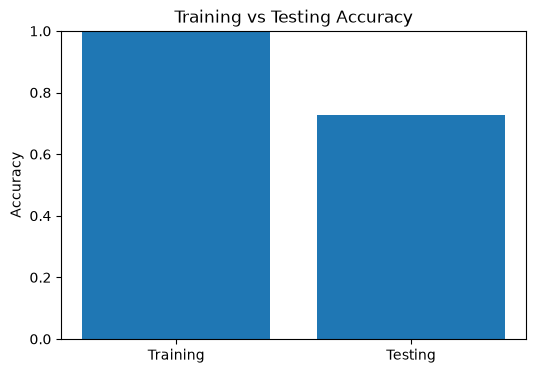

In [19]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Dataset"],
    comparison["Accuracy"]
)

plt.ylim(0,1)

plt.ylabel("Accuracy")

plt.title("Training vs Testing Accuracy")

plt.show()

## Hyperparameter Tuning

Decision Trees are highly sensitive to their hyperparameters.

To improve generalization and reduce overfitting, GridSearchCV is used to search for the optimal combination of hyperparameters.

The following parameters are tuned:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

In [20]:
param_grid = {
    "classifier__criterion": [
        "gini",
        "entropy"
    ],

    "classifier__max_depth": [
        3,
        5,
        7,
        10,
        None
    ],

    "classifier__min_samples_split": [
        2,
        5,
        10,
        20
    ],

    "classifier__min_samples_leaf": [
        1,
        2,
        4,
        8
    ]
}

In [21]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

In [22]:
grid_search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__criterion': ['gini', 'entropy'], 'classifier__max_depth': [3, 5, ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... version

In [23]:
print("Best Parameters:")
print(grid_search.best_params_)

print()

print("Best ROC-AUC:")
print(grid_search.best_score_)

Best Parameters:
{'classifier__criterion': 'gini', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10}

Best ROC-AUC:
0.825707969259922


In [24]:
best_pipeline = grid_search.best_estimator_

In [25]:
y_pred = best_pipeline.predict(X_test)

y_prob = best_pipeline.predict_proba(X_test)[:, 1]

In [26]:
test_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

test_summary = pd.DataFrame(
    test_results.items(),
    columns=["Metric", "Score"]
)

test_summary["Score"] = test_summary["Score"].round(4)

test_summary

,Metric,Score
0,Accuracy,0.7839
1,Precision,0.5862
2,Recall,0.6364
3,F1-Score,0.6103
4,ROC-AUC,0.8221


In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1033
           1       0.59      0.64      0.61       374

    accuracy                           0.78      1407
   macro avg       0.73      0.74      0.73      1407
weighted avg       0.79      0.78      0.79      1407



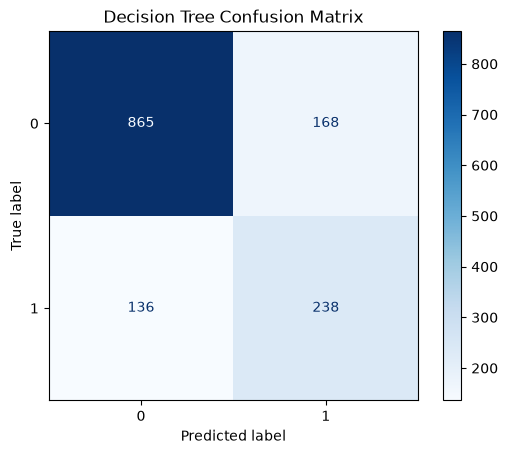

In [28]:
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot(cmap="Blues")

plt.title("Decision Tree Confusion Matrix")

plt.show()

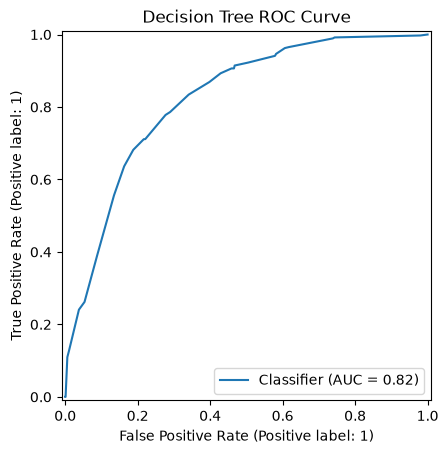

In [29]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Decision Tree ROC Curve")

plt.show()

In [30]:
feature_names = best_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_pipeline.named_steps[
        "classifier"
    ].feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
39,nominal__Contract_Month-to-month,0.515886
19,nominal__InternetService_Fiber optic,0.149341
2,continuous__TotalCharges,0.117397
0,continuous__tenure,0.065467
3,continuous__AvgMonthlySpend,0.043973
30,nominal__TechSupport_No,0.027461
1,continuous__MonthlyCharges,0.019595
46,nominal__PaymentMethod_Electronic check,0.013612
41,nominal__Contract_Two year,0.011691
14,nominal__PhoneService_Yes,0.009390


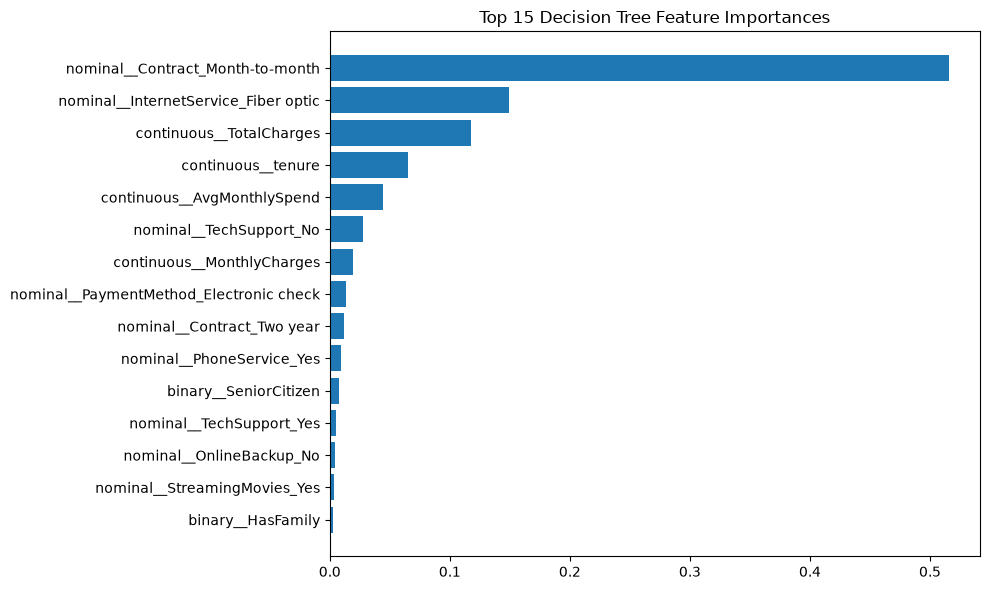

In [31]:
top15 = importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top15["Feature"],
    top15["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Decision Tree Feature Importances")

plt.tight_layout()

plt.show()

In [32]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        0.8010,
        0.6442,
        0.5615,
        0.6000,
        0.8350
    ],
    "Decision Tree": test_summary["Score"]
})

comparison

,Metric,Logistic Regression,Decision Tree
0,Accuracy,0.8010,0.7839
1,Precision,0.6442,0.5862
2,Recall,0.5615,0.6364
3,F1,0.6000,0.6103
4,ROC-AUC,0.8350,0.8221


In [33]:
comparison["Winner"] = [
    "Logistic Regression",
    "Logistic Regression",
    "Decision Tree",
    "Decision Tree",
    "Logistic Regression"
]

comparison

,Metric,Logistic Regression,Decision Tree,Winner
0,Accuracy,0.8010,0.7839,Logistic Regression
1,Precision,0.6442,0.5862,Logistic Regression
2,Recall,0.5615,0.6364,Decision Tree
3,F1,0.6000,0.6103,Decision Tree
4,ROC-AUC,0.8350,0.8221,Logistic Regression


## Model Comparison

The tuned Decision Tree significantly improved over the baseline Decision Tree after hyperparameter tuning.

Compared with Logistic Regression:

- Logistic Regression achieved higher overall Accuracy.
- Logistic Regression achieved higher Precision.
- Logistic Regression achieved a slightly higher ROC-AUC.
- Decision Tree achieved higher Recall.
- Decision Tree achieved the highest F1-score.

These results demonstrate that different machine learning algorithms optimize different aspects of predictive performance.

If the primary business objective is to identify as many potential churners as possible, the Decision Tree may be preferred due to its higher Recall.

If overall predictive reliability is the priority, Logistic Regression remains the stronger baseline model.

## Save Model

The final Decision Tree pipeline is serialized using Joblib.

Saving the complete pipeline ensures that preprocessing and prediction remain identical during deployment and future inference.

In [35]:
import joblib

joblib.dump(
    best_pipeline,
    "../models/decision_tree_pipeline.pkl"
)

print("Decision Tree model saved successfully.")

Decision Tree model saved successfully.


In [36]:
cv_summary.to_csv(
    "../reports/decision_tree_cv.csv",
    index=False
)